In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
import optuna

In [2]:
df = pd.read_csv('historical_data.csv')
df.head(20)

,client_id,age,income,education,gender,employment_status,years_employed,marital_status,num_dependents,home_ownership,credit_history_length,num_credit_lines,num_past_defaults,dti_ratio,credit_utilization,existing_loan_amount,credit_score,region,desired_credit_limit,default_within_1y
0,987232,21.0,27104.33,NaN,Female,Retired,28.8,Married,0,Mortgage,14.9,2,2,NaN,0.703,34983.41,566.0,Urban,11489.47,1
1,79955,44.0,16862.17,NaN,Male,Self-Employed,2.2,Married,1,Mortgage,11.8,1,1,0.039,0.467,17232.52,599.0,Rural,18024.43,0
2,567131,29.0,42902.03,NaN,Female,Employed,9.9,Married,2,Rent,3.4,2,0,0.340,0.074,21534.80,704.0,Suburban,50290.26,0
3,500892,40.0,33427.68,Bachelor,Male,NaN,0.9,Divorced,1,Own,15.3,4,2,0.047,0.555,5413.00,554.0,Rural,32839.29,1
4,55400,NaN,12398.00,Bachelor,Female,Employed,3.8,Married,0,Mortgage,21.0,2,1,0.458,0.112,818.34,741.0,Rural,5899.81,0
5,135050,21.0,NaN,Master,Female,Self-Employed,1.0,Married,1,Own,15.1,4,0,0.239,0.257,45519.95,690.0,Suburban,46057.04,1
6,733379,21.0,71923.03,NaN,Female,Employed,0.9,Married,2,Mortgage,NaN,6,1,0.168,0.235,55072.52,675.0,Suburban,59840.33,0
7,732058,NaN,55307.72,Bachelor,Male,Unemployed,3.9,Married,0,Own,9.4,0,0,0.387,0.433,70148.41,646.0,Suburban,43619.33,0
8,51334,NaN,28226.54,Bachelor,Female,Unemployed,1.6,Married,3,Mortgage,11.0,1,0,0.218,0.319,29773.56,620.0,Urban,29805.28,0
9,731480,36.0,NaN,HighSchool,Male,Employed,13.7,Single,1,Rent,7.6,3,0,0.444,0.660,109551.27,603.0,Suburban,54921.97,1


In [3]:
TARGET = "default_within_1y"
ID_COL = "client_id"


print("Dataset shape:")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(
    pd.DataFrame({
        "dtype": df.dtypes,
        "n_unique": df.nunique(),
        "missing": df.isna().sum(),
        "missing_pct": df.isna().mean() * 100
    }).sort_values("missing_pct", ascending=False)
)

Dataset shape:
Rows:    1,000,000
Columns: 20

Column names:
['client_id', 'age', 'income', 'education', 'gender', 'employment_status', 'years_employed', 'marital_status', 'num_dependents', 'home_ownership', 'credit_history_length', 'num_credit_lines', 'num_past_defaults', 'dti_ratio', 'credit_utilization', 'existing_loan_amount', 'credit_score', 'region', 'desired_credit_limit', 'default_within_1y']

Data types:


,dtype,n_unique,missing,missing_pct
education,str,4,54229,5.4229
employment_status,str,4,4831,0.4831
credit_score,float64,452,4807,0.4807
credit_history_length,float64,6021,4781,0.4781
dti_ratio,float64,9221,4777,0.4777
income,float64,920617,4770,0.4770
age,float64,67,4727,0.4727
num_past_defaults,int64,7,0,0.0000
desired_credit_limit,float64,910884,0,0.0000
region,str,3,0,0.0000


<H1> EDA <H1>

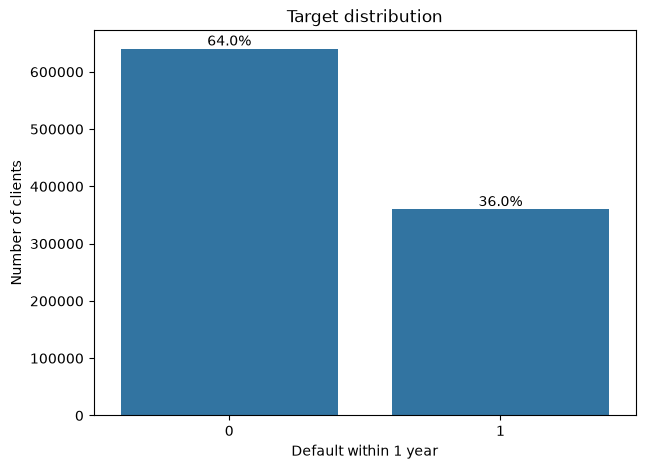

In [4]:
# Посмотрим на распределение таргета 
target_counts = df[TARGET].value_counts(dropna=False).sort_index()
target_share = df[TARGET].value_counts(
    normalize=True,
    dropna=False
).sort_index()

target_summary = pd.DataFrame({
    "count": target_counts,
    "share": target_share
})

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Target distribution")
plt.xlabel("Default within 1 year")
plt.ylabel("Number of clients")
total = len(df)

for container in ax.containers:
    labels = [
        f"{bar.get_height() / total:.1%}"
        for bar in container
    ]
    ax.bar_label(container, labels=labels)

plt.show()

Заметим, что сильного дисбаланса классов здесь нет, то есть по сути можно специально отдельно его не обрабатывать 


In [5]:
# посмотрим на распределения числовых признаков
numeric_features = df.select_dtypes(
    include=np.number
).columns.tolist()

numeric_features = [
    col for col in numeric_features
    if col not in [TARGET, ID_COL]
]

numeric_summary = df[numeric_features].describe().T
numeric_summary["missing"] = df[numeric_features].isna().sum()
numeric_summary["missing_pct"] = (
    df[numeric_features].isna().mean() * 100
)

display(numeric_summary)

,count,mean,std,min,25%,50%,75%,max,missing,missing_pct
age,995273.0,41.514878,3.795294e+01,-5.000000,32.0000,40.000,48.0000,9.990000e+02,4727,0.4727
income,995230.0,142789.590859,1.186293e+06,-49979.520607,25830.6300,36388.220,51279.0025,2.029259e+07,4770,0.4770
years_employed,1000000.0,4.999215,4.987925e+00,0.000000,1.4000,3.500,6.9000,4.000000e+01,0,0.0000
num_dependents,1000000.0,1.201603,1.095976e+00,0.000000,0.0000,1.000,2.0000,8.000000e+00,0,0.0000
credit_history_length,995219.0,11.852056,6.352123e+00,-29.988243,7.6000,11.000,15.3000,5.000000e+01,4781,0.4781
num_credit_lines,1000000.0,4.019079,1.188529e+01,0.000000,2.0000,3.000,4.0000,1.990000e+02,0,0.0000
num_past_defaults,1000000.0,0.400036,6.327777e-01,0.000000,0.0000,0.000,1.0000,6.000000e+00,0,0.0000
dti_ratio,995223.0,0.387436,1.189330e+00,0.000000,0.1620,0.266,0.3930,1.999838e+01,4777,0.4777
credit_utilization,1000000.0,0.390784,2.356692e-01,-1.999783,0.2410,0.384,0.5420,9.950000e-01,0,0.0000
existing_loan_amount,1000000.0,131038.803125,1.135642e+06,-19997.332880,11912.3100,24839.810,42899.1000,1.761798e+07,0,0.0000


Очевидно, что всякие отрицательные age и прочие выбросы стоит почистить. Их я буду заполнять NaN-ами, так как в дальнейшем планирую использовать LigthGBM в качестве модели машинного обучения


In [6]:
df.loc[(df["age"] < 18) | (df["age"] > 100), "age"] = np.nan
df.loc[df["income"] < 0, "income"] = np.nan
df.loc[df["credit_history_length"] < 0, "credit_history_length"] = np.nan
df.loc[
    (df["credit_utilization"] < 0) |
    (df["credit_utilization"] > 1),
    "credit_utilization"
] = np.nan
df.loc[df["existing_loan_amount"] < 0, "existing_loan_amount"] = np.nan

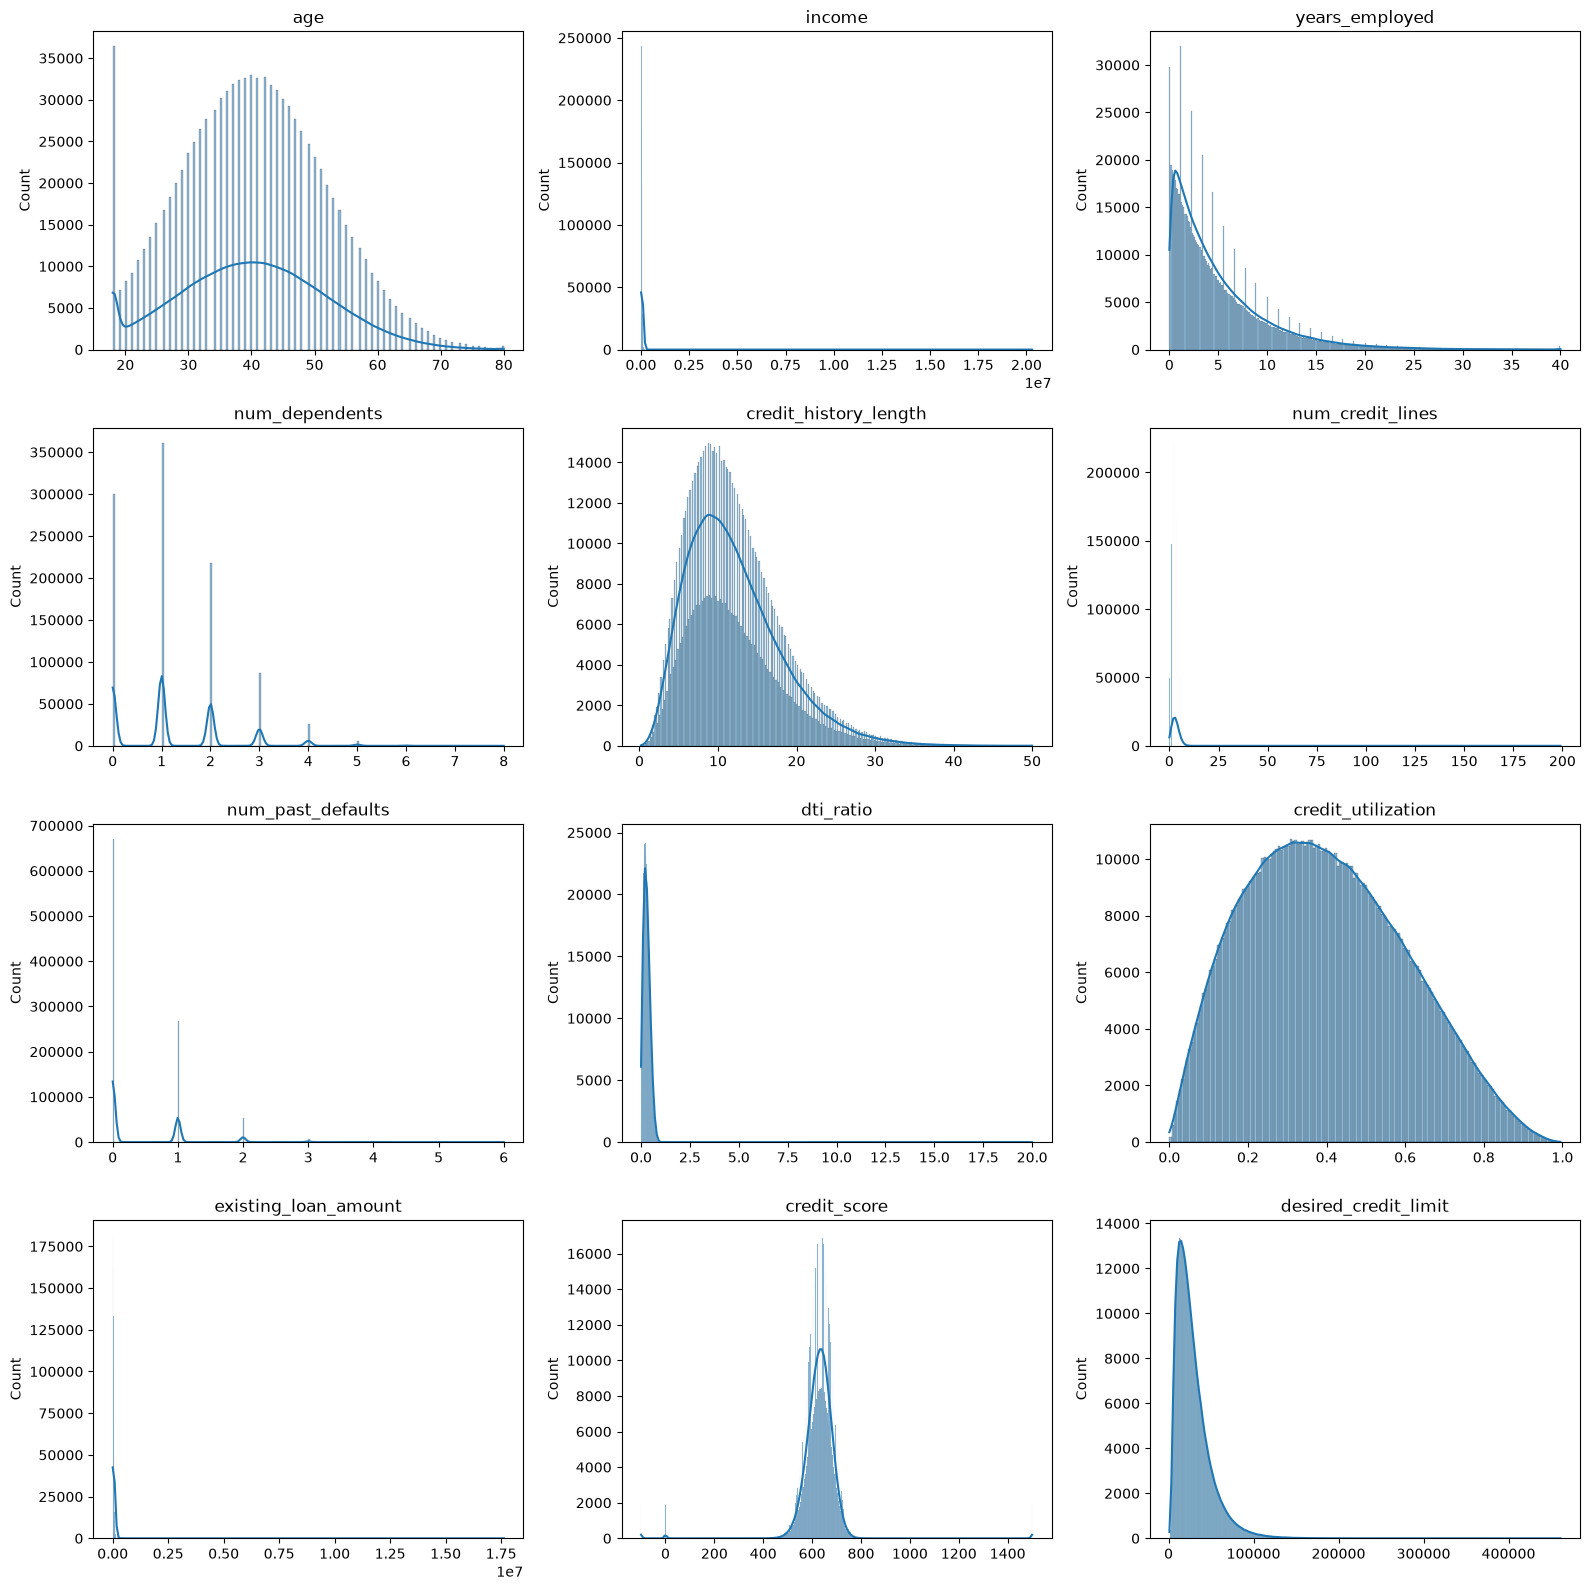

In [7]:
def plot_numeric_distributions(data, features, ncols=3):
    
    nrows = int(np.ceil(len(features) / ncols))

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4 * nrows)
    )

    axes = np.array(axes).reshape(-1)

    for ax, feature in zip(axes, features):

        sns.histplot(
            data=data,
            x=feature,
            kde=True,
            ax=ax
        )

        ax.set_title(feature)
        ax.set_xlabel("")
    
    for ax in axes[len(features):]:
        ax.remove()

    plt.tight_layout()
    plt.show()


plot_numeric_distributions(df, numeric_features)

In [8]:
# перейдем к категориальным признакам
categorical_features = df.select_dtypes(
    include=["object", "category", "str"]
).columns.tolist()

categorical_features = [
    col for col in categorical_features
    if col not in [TARGET, ID_COL]
]

categorical_summary = pd.DataFrame({
    "n_unique": df[categorical_features].nunique(),
    "missing": df[categorical_features].isna().sum(),
    "missing_pct": df[categorical_features].isna().mean() * 100
}).sort_values("n_unique", ascending=False)

display(categorical_summary)

,n_unique,missing,missing_pct
education,4,54229,5.4229
employment_status,4,4831,0.4831
marital_status,4,0,0.0000
home_ownership,3,0,0.0000
region,3,0,0.0000
gender,2,0,0.0000


In [9]:
for feature in categorical_features:

    summary = (
        df.groupby(feature, dropna=False)[TARGET]
        .agg(
            count="size",
            default_rate="mean"
        )
        .sort_values("default_rate", ascending=False)
    )

    print(f"\n{'=' * 40}")
    print(f"{feature}")

    display(summary)


education


,count,default_rate
education,,
NaN,54229,0.500839
HighSchool,348583,0.416495
Bachelor,348590,0.341120
Master,198660,0.282991
PhD,49938,0.247527



gender


,count,default_rate
gender,,
Female,499731,0.360010
Male,500269,0.359659



employment_status


...

,count,default_rate
marital_status,,
Divorced,149954,0.361484
Widowed,49729,0.360796
Married,450461,0.359836
Single,349856,0.358988



home_ownership


,count,default_rate
home_ownership,,
Mortgage,400924,0.360859
Own,300049,0.359551
Rent,299027,0.358744



region


,count,default_rate
region,,
Urban,501199,0.360460
Rural,198392,0.360161
Suburban,300409,0.358574


Насколько я понял, никаких крутых инсайдов здесь нет, всё вполне логично и понятно

In [10]:
# глянем на связь числовых признаков с дефолтом, для этого проведем quantile binning и посмотрим на графики
def target_rate_by_quantile(
    data,
    feature,
    target,
    q=10
):
    """
    Divide a numerical feature into quantile bins
    and calculate target rate in each bin.
    """

    temp = data[[feature, target]].copy()

    temp["bin"] = pd.qcut(
        temp[feature],
        q=q,
        duplicates="drop"
    )

    result = (
        temp.groupby("bin", observed=True)[target]
        .agg(
            count="size",
            target_rate="mean"
        )
        .reset_index()
    )

    return result

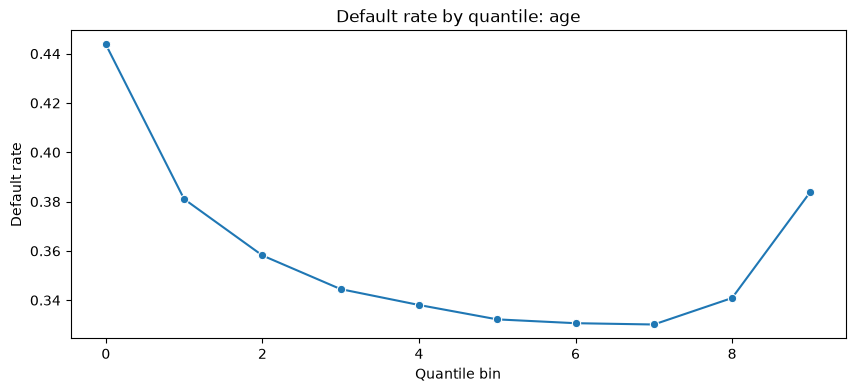

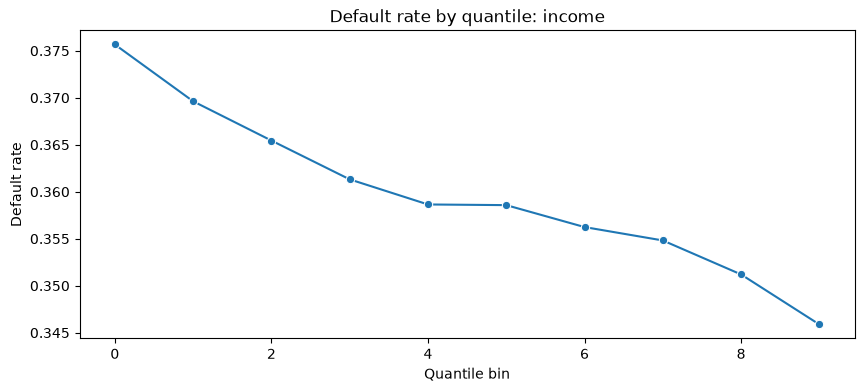

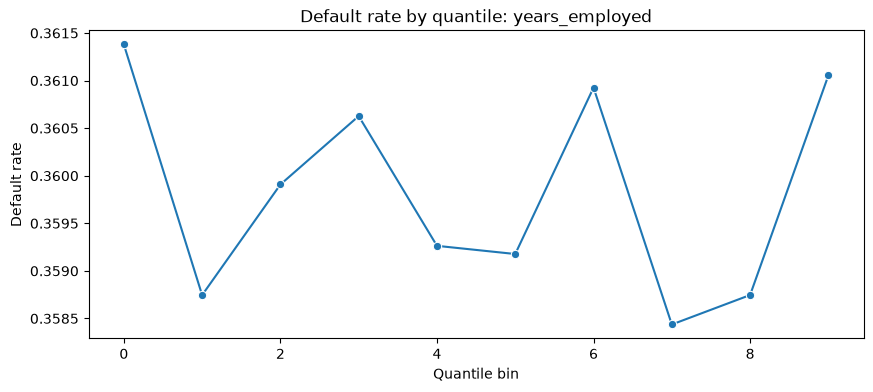

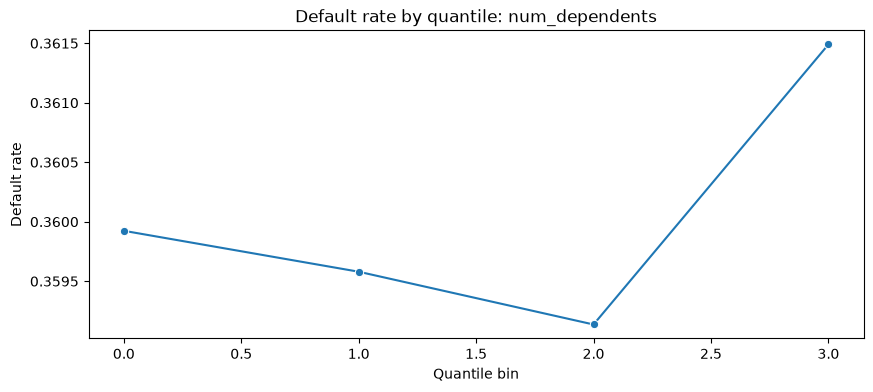

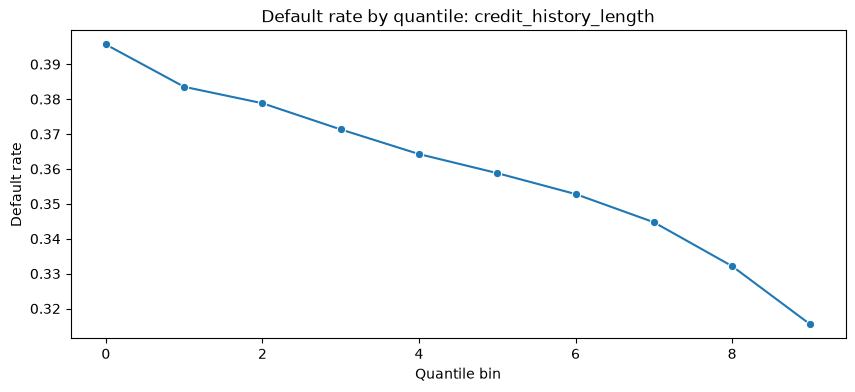

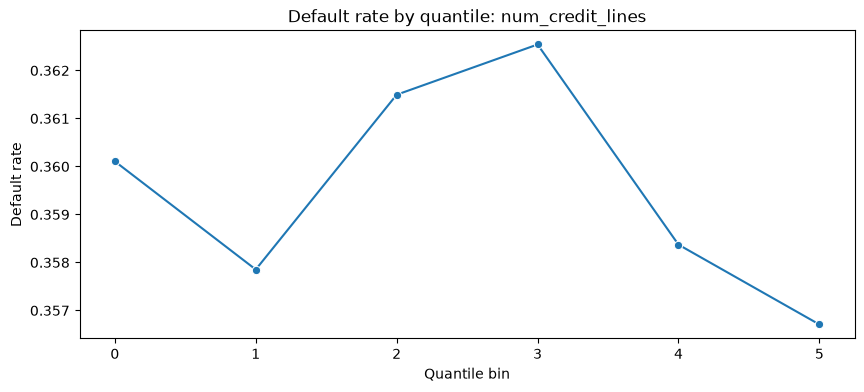

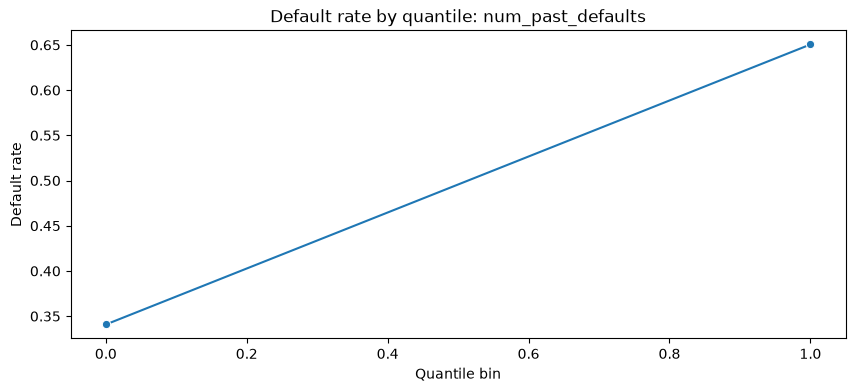

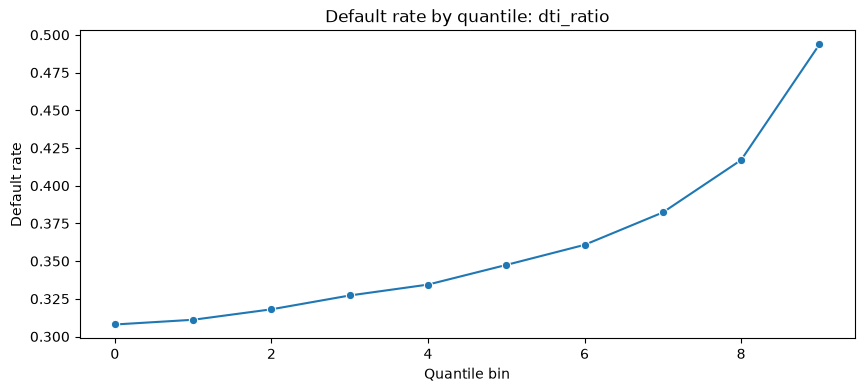

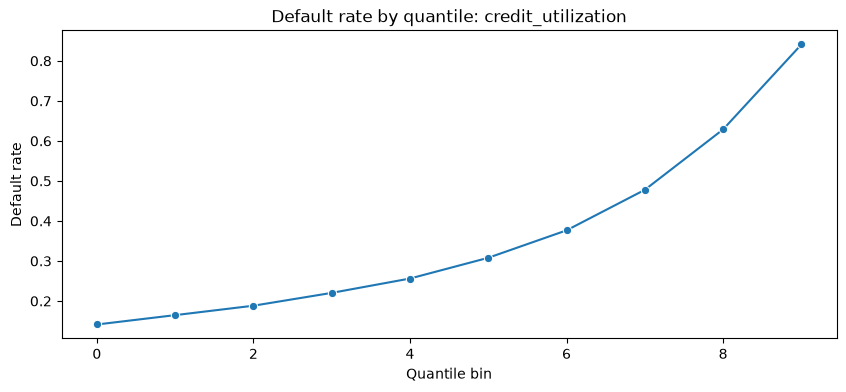

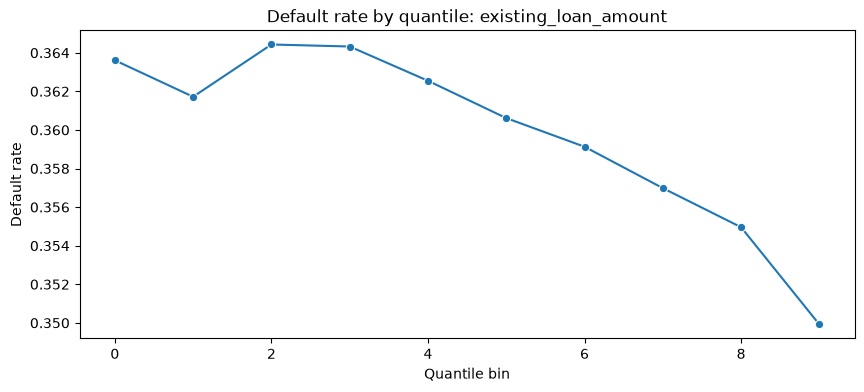

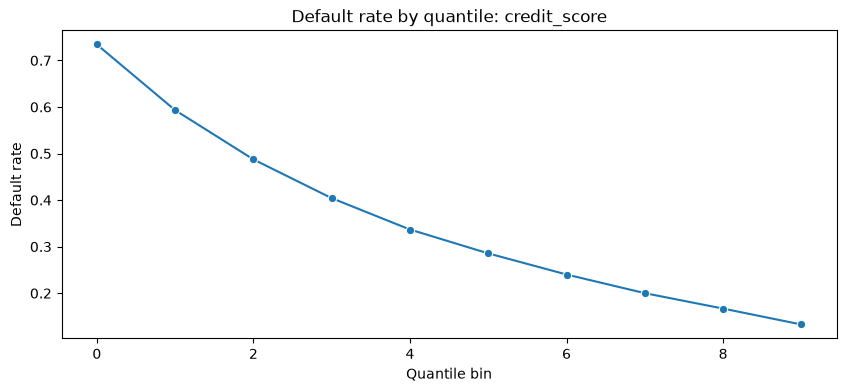

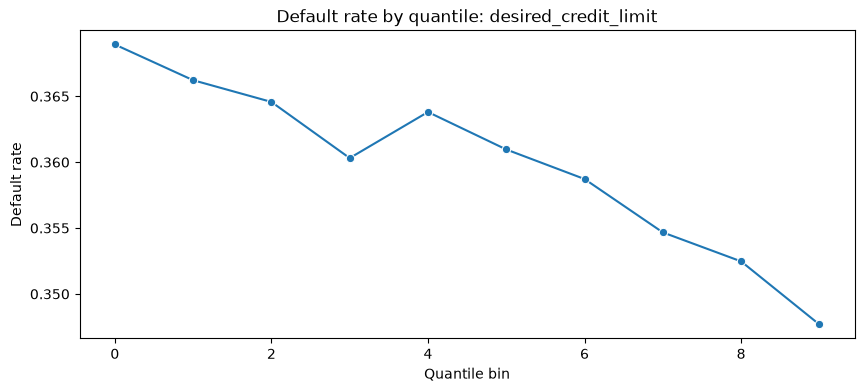

In [11]:
def plot_target_rate_by_quantile(
    data,
    feature,
    target,
    q=10
):
    result = target_rate_by_quantile(
        data,
        feature,
        target,
        q
    )

    plt.figure(figsize=(10, 4))

    sns.lineplot(
        data=result,
        x=result.index,
        y="target_rate",
        marker="o"
    )

    plt.title(f"Default rate by quantile: {feature}")
    plt.xlabel("Quantile bin")
    plt.ylabel("Default rate")

    plt.show()


for feature in numeric_features:
    plot_target_rate_by_quantile(
        df,
        feature,
        TARGET
    )

Опять же, никаких интересных или скрытых закономерностей - всё вполне логично, единственное меня немного смущает years_employed. Хотя, c другой стороны, раз уж ниче подозрительного нет, то датасету можно верить и моделька че-нибудь да напредиктит)))

<H1> Обучение модели

Не буду сильно много тут расписывать, ведь причины для того, чтоб выбрать именно бустинг были достаточно просты. 
1) В данном задании передо мной не стоит задача объяснять бизнесу то, как работает моя модель, соответственно плюс логистической регрессии в ее интерпретируемости пропадает. К тому же, при оптимизации признаков для линейной регресии многие преобразования будут проводиться вручную мной, что увеличивает вероятность ошибки.
2) Всё-таки известно, что на табличных данных бустинги добиваются лучших результатов, чем нейронные сети, поэтому их я тоже откинул

In [12]:
# разбиваем на train, test и validation
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])
X = X.drop(columns=[ID_COL]) # client_id удаляем, так как бесполезен
RANDOM_STATE = 42


# Первый split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

# Второй split: из temporary получаем validation и test по 15%
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE
)


print("Train:")
print(X_train.shape, y_train.shape)

print("\nValidation:")
print(X_valid.shape, y_valid.shape)

print("\nTest:")
print(X_test.shape, y_test.shape)

Train:
(700000, 18) (700000,)

Validation:
(150000, 18) (150000,)

Test:
(150000, 18) (150000,)


In [ ]:
# сразу подготовим словарь для дальнейшей работы с OOT.csv
from sklearn.preprocessing import LabelEncoder

encoders = {}  # словарь для хранения обученных кодировщиков

for col in categorical_features:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    X_valid[col] = le.transform(X_valid[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))
    encoders[col] = le

print(encoders)

{'education': LabelEncoder(), 'gender': LabelEncoder(), 'employment_status': LabelEncoder(), 'marital_status': LabelEncoder(), 'home_ownership': LabelEncoder(), 'region': LabelEncoder()}


In [38]:
# сначала вообще определим функцию, по которой будем считать прибыль
def calculate_profit(y_true, y_pred_proba, X, threshold=0.5):
    
    credit_limits = X["desired_credit_limit"].values

    approved = y_pred_proba < threshold
    
    profit = np.zeros(len(y_true))
    
    # Одобрили кредит и клиент НЕ дефолтнул
    good_client = approved & (y_true == 0)
    profit[good_client] = credit_limits[good_client] * 0.18
    
    # Одобрили кредит и клиент дефолтнул
    bad_client = approved & (y_true == 1)
    profit[bad_client] = -credit_limits[bad_client] * 0.75
    
    return profit.sum()

In [ ]:
# Optuna подбирает гиперпараметры LightGBM непосредственно под бизнес-метрику — совокупную чистую прибыль на validation.
# Модель прогнозирует PD, поэтому внутри calculate_profit() используется правило: approve if P(default) < threshold

def objective(trial, X_train, y_train, X_valid, y_valid):

    params = {
        "objective": "binary",
        "metric": "auc",
        "verbosity": -1,
        "boosting_type": "gbdt",
        "random_state": RANDOM_STATE,
        "num_leaves": trial.suggest_int("num_leaves", 10, 200),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "feature_fraction": trial.suggest_float("feature_fraction", 0.5, 1.0),
        "bagging_fraction": trial.suggest_float("bagging_fraction", 0.5, 1.0),
        "bagging_freq": trial.suggest_int("bagging_freq", 1, 10),
        "lambda_l1": trial.suggest_float("lambda_l1", 1e-8, 10.0, log=True),
        "lambda_l2": trial.suggest_float("lambda_l2", 1e-8, 10.0, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_split_gain": trial.suggest_float("min_split_gain", 0.0, 1.0),
    }

    train_data = lgb.Dataset(X_train, label=y_train)
    valid_data = lgb.Dataset(X_valid, label=y_valid, reference=train_data)

    model = lgb.train(
        params,
        train_data,
        num_boost_round=1000,
        valid_sets=[valid_data],
        callbacks=[
            lgb.early_stopping(
                20,
                verbose=False
            )
        ]
    )

    # вероятность дефолта
    preds = model.predict(
        X_valid,
        num_iteration=model.best_iteration
    )

    # одобряем клиента, если P(default) < threshold.
    thresholds = np.arange(0.01, 0.50, 0.001)

    profits = [
        calculate_profit(
            y_valid,
            preds,
            X_valid,
            threshold=th
        )
        for th in thresholds
    ]

    best_idx = np.argmax(profits)

    best_profit = profits[best_idx]
    best_threshold = thresholds[best_idx]

    trial.set_user_attr(
        "best_threshold",
        float(best_threshold)
    )

    trial.set_user_attr(
        "best_iteration",
        int(model.best_iteration)
    )

    return best_profit

In [ ]:
study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(lambda trial: objective(trial, X_train, y_train, X_valid, y_valid), n_trials=50)

# лучшие параметры
best_params = study.best_params
best_params.update({'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42})

# лучший порог 
best_threshold = 0.5
best_profit_val = -float('inf')
for trial in study.trials:
    if trial.user_attrs.get('best_profit', -float('inf')) > best_profit_val:
        best_profit_val = trial.user_attrs.get('best_profit', -float('inf'))
        best_threshold = trial.user_attrs.get('best_threshold', 0.5)

print(f"Лучшие параметры: {best_params}")
print(f"Лучшая прибыль на валидации: {best_profit_val:,.0f}")
print(f"Оптимальный порог: {best_threshold:.2f}")

# обучаем финальную модель на объединённых train+val 
X_train_full = pd.concat([X_train, X_valid], axis=0)
y_train_full = np.concatenate([y_train, y_valid])

train_full_data = lgb.Dataset(X_train_full, label=y_train_full)
model_final = lgb.train(
    best_params,
    train_full_data,
    num_boost_round=1000,
    valid_sets=[lgb.Dataset(X_valid, label=y_valid)],
    callbacks=[lgb.early_stopping(20, verbose=False)]
)

# оценка на тесте
preds_test = model_final.predict(X_test, num_iteration=model_final.best_iteration)
auc_test = roc_auc_score(y_test, preds_test)
profit_test = calculate_profit(y_test, preds_test, X_test, best_threshold)

print(f"Test AUC: {auc_test:.4f}")
print(f"Test Profit: {profit_test:,.0f}")

[I 2026-08-19 21:21:13,900] A new study created in memory with name: no-name-bfb69da2-0630-4016-90b3-c70bdca7249e
[I 2026-08-19 21:21:16,061] Trial 0 finished with value: 136434464.4105 and parameters: {'num_leaves': 81, 'learning_rate': 0.2536999076681771, 'feature_fraction': 0.8659969709057025, 'bagging_fraction': 0.7993292420985183, 'bagging_freq': 2, 'lambda_l1': 2.5348407664333426e-07, 'lambda_l2': 3.3323645788192616e-08, 'min_child_samples': 88, 'max_depth': 9, 'min_split_gain': 0.7080725777960455}. Best is trial 0 with value: 136434464.4105.
[I 2026-08-19 21:21:18,455] Trial 1 finished with value: 136633282.6056 and parameters: {'num_leaves': 13, 'learning_rate': 0.27081608642499677, 'feature_fraction': 0.9162213204002109, 'bagging_fraction': 0.6061695553391381, 'bagging_freq': 2, 'lambda_l1': 4.4734294104626844e-07, 'lambda_l2': 5.472429642032189e-06, 'min_child_samples': 55, 'max_depth': 7, 'min_split_gain': 0.2912291401980419}. Best is trial 1 with value: 136633282.6056.
[I 2

Лучшие параметры: {'num_leaves': 73, 'learning_rate': 0.08953165652762064, 'feature_fraction': 0.5538575878787325, 'bagging_fraction': 0.8491625762898385, 'bagging_freq': 10, 'lambda_l1': 0.018016534775424576, 'lambda_l2': 2.816433263597621e-06, 'min_child_samples': 70, 'max_depth': 7, 'min_split_gain': 0.14417995884642623, 'objective': 'binary', 'metric': 'auc', 'verbosity': -1, 'random_state': 42}
Лучшая прибыль на валидации: -inf
Оптимальный порог: 0.50
Test AUC: 0.8369
Test Profit: 11,071,743


In [ ]:
# фиксируем лучшие параметры, найденные Optuna
best_trial = study.best_trial

best_params = best_trial.params.copy()

best_threshold = best_trial.user_attrs["best_threshold"]
best_iteration = best_trial.user_attrs["best_iteration"]

print(f"Best trial: {best_trial.number}")
print(f"Validation profit from Optuna: {best_trial.value:,.2f}")
print(f"Best threshold: {best_threshold:.4f}")
print(f"Best iteration: {best_iteration}")

print("\nBest parameters:")
for param, value in best_params.items():
    print(f"{param}: {value}")

Best trial: 46
Validation profit from Optuna: 138,071,068.55
Best threshold: 0.2010
Best iteration: 123

Best parameters:
num_leaves: 73
learning_rate: 0.08953165652762064
feature_fraction: 0.5538575878787325
bagging_fraction: 0.8491625762898385
bagging_freq: 10
lambda_l1: 0.018016534775424576
lambda_l2: 2.816433263597621e-06
min_child_samples: 70
max_depth: 7
min_split_gain: 0.14417995884642623


In [ ]:
# обучаем LightGBM с лучшими параметрами Optuna
best_model = lgb.LGBMClassifier(
    **best_params,
    n_estimators=best_iteration,
    random_state=42,
    verbosity=-1
)

best_model.fit(
    X_train,
    y_train
)
    

Модель обучена.
Количество деревьев: 123


In [ ]:
# финальная оценка модели на тестовой выборке

test_pred_proba = best_model.predict_proba(X_test)[:, 1]

test_profit = calculate_profit(
    y_test,
    test_pred_proba,
    X_test,
    threshold=best_threshold
)

test_approved = test_pred_proba < best_threshold

print(f"Test profit: {test_profit:,.2f}")
print(f"Decision threshold: {best_threshold:.4f}")
print(f"Approval rate: {test_approved.mean():.2%}")

Test profit: 136,382,468.47
Decision threshold: 0.2010
Approval rate: 44.16%


In [ ]:
# основные бизнес-метрики на тестовой выборке
approved = test_pred_proba < best_threshold

n_approved = approved.sum()
n_rejected = (~approved).sum()

default_rate_approved = y_test[approved].mean()

approved_credit_limit = X_test.loc[
    approved,
    "desired_credit_limit"
].sum()

print(f"Одобрено: {n_approved:,} ({approved.mean():.2%})")
print(f"Отклонено: {n_rejected:,} ({(~approved).mean():.2%})")
print(f"Default rate среди одобренных: {default_rate_approved:.2%}")
print(f"Суммарный одобренный лимит: {approved_credit_limit:,.2f}")
print(f"Test profit: {test_profit:,.2f}")

Одобрено: 66,243 (44.16%)
Отклонено: 83,757 (55.84%)
Default rate среди одобренных: 11.75%
Суммарный одобренный лимит: 1,938,332,504.71
Test profit: 136,382,468.47


<h1> Проверка через OOT.csv


ниже идет уже полный вайбкод, надеюсь всё заработает, но вообще здесь просто должны пройти все те же небольшие преобразования с фичами, что я делал в historical_data.csv

In [ ]:
# Загрузка
df_oot = pd.read_csv('OOT.csv')

# Сохраним исходные данные для финального вывода (с сохранением всех колонок)
df_oot_out = df_oot.copy()

# Удаляем client_id (он не нужен для предсказания)
X_oot = df_oot.drop(columns=[ID_COL], errors='ignore')

# Если в OOT есть целевая переменная, её тоже удаляем из признаков (но сохраняем в выводе)
if TARGET in X_oot.columns:
    X_oot = X_oot.drop(columns=[TARGET])

# Применяем те же правила очистки выбросов (как для обучающих данных)
X_oot.loc[(X_oot["age"] < 18) | (X_oot["age"] > 100), "age"] = np.nan
X_oot.loc[X_oot["income"] < 0, "income"] = np.nan
X_oot.loc[X_oot["credit_history_length"] < 0, "credit_history_length"] = np.nan
X_oot.loc[(X_oot["credit_utilization"] < 0) | (X_oot["credit_utilization"] > 1), "credit_utilization"] = np.nan
X_oot.loc[X_oot["existing_loan_amount"] < 0, "existing_loan_amount"] = np.nan

# Кодируем категориальные признаки с использованием сохранённых encoders
for col in categorical_features:
    # Преобразуем в строку, чтобы избежать ошибок с NaN
    X_oot[col] = X_oot[col].astype(str)
    # Для неизвестных категорий можно заменить на -1 (но в наших данных все категории известны)
    # Если встретится новая категория, LabelEncoder выдаст ошибку – обработаем это:
    try:
        X_oot[col] = encoders[col].transform(X_oot[col])
    except ValueError:
        # Если новая категория, заменяем на -1 (или на другую заглушку)
        # Для простоты просто пропускаем, но лучше заменить на -1
        known_classes = set(encoders[col].classes_)
        X_oot[col] = X_oot[col].apply(lambda x: x if x in known_classes else 'unknown')
        # Добавляем 'unknown' в классы и переобучаем encoder (не рекомендуется, лучше использовать pd.Categorical)
        # Более надёжно: использовать pandas Categorical с категориями из train
        # Ниже альтернативный способ
        # X_oot[col] = pd.Categorical(X_oot[col], categories=encoders[col].classes_)
        # X_oot[col] = X_oot[col].cat.codes

# Альтернативный способ кодирования с фиксированными категориями:
# for col in categorical_features:
#     X_oot[col] = pd.Categorical(X_oot[col], categories=encoders[col].classes_).codes
# Но этот способ заменит новые категории на -1 автоматически.

# Используем второй способ, более чистый:
for col in categorical_features:
    X_oot[col] = pd.Categorical(X_oot[col], categories=encoders[col].classes_).codes
# Примечание: значения, не вошедшие в категории, получат код -1.

In [ ]:
# Предсказание вероятности дефолта с помощью модели, обученной на train+valid
pred_proba_oot = model_final.predict_proba(X_oot)[:, 1]  # или .predict() если нужны только вероятности

# Применяем оптимальный порог (получен на валидации)
approved = (pred_proba_oot < best_threshold).astype(int)  # 1 – одобрено, 0 – отклонено

# Добавляем колонку в итоговый DataFrame
df_oot_out['approved'] = approved

# Покажем первые строки
print(df_oot_out.head())